### **Exploratory Data Analysis**

This notebook will conduct analysis on the ACLED *df_filtered* dataframe from **01_data_cleaning**.

The goal of this notebook will be to characterise distribution of state and non-state violence, identify key patterns in event types and fatalities, and produce initial visualisations of data comparison. This shall drive the focused analysis of notebook **03_analysis.ipynb**.

Import Python libraries and Google Drive.

In [ ]:
import pandas as pd
import os
import gdown

# Import NumPy for mathematical analysis.
import numpy as np

# Import MatPlotLib for data visualisation.
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Import Seaborn (wrap-around for MatPlotLib) for visualisation shortcuts.
import seaborn as sns

# Import Drive.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Import datafile and print for later reference.

In [ ]:
# Load filtered dataset from Notebook 1 (extract ID from Drive URL)
drive_file_id = '1LhYVy64volmFM7oS868R5AvmpZ4W0loO'
local_file_path = 'df_filtered.pkl'
gdown.download(id=drive_file_id, output=local_file_path, quiet=False)
df_filtered = pd.read_pickle(local_file_path)

# Add time columns for later analysis.
df_filtered['year_month'] = df_filtered['event_date'].dt.to_period('M')

print(f"Dataset loaded: {df_filtered.shape[0]:,} rows × {df_filtered.shape[1]} columns")
print(f"Date range: {df_filtered['event_date'].min().date()} → {df_filtered['event_date'].max().date()}")
print(f"Columns: {df_filtered.columns.tolist()}")

Downloading...
From: https://drive.google.com/uc?id=1LhYVy64volmFM7oS868R5AvmpZ4W0loO
To: /content/df_filtered.pkl
100%|██████████| 29.4M/29.4M [00:00<00:00, 85.1MB/s]


Dataset loaded: 195,807 rows × 25 columns
Date range: 2018-01-01 → 2024-12-31
Columns: ['event_date', 'year', 'time_precision', 'disorder_type', 'event_type', 'sub_event_type', 'actor1', 'inter1', 'actor2', 'inter2', 'interaction', 'country', 'admin1', 'admin2', 'location', 'latitude', 'longitude', 'geo_precision', 'source_scale', 'fatalities', 'actor1_type', 'actor2_type', 'is_state_actor_event', 'is_non_state_actor_event', 'year_month']


Produce summary/statistical overview of scale, temporal scale, and state/non-state difference inputted in Notebook 1.

In [ ]:
# Define state and non-state subsets based on flags from Notebook 1.
state_events     = df_filtered[df_filtered['is_state_actor_event'] == 1]
non_state_events = df_filtered[df_filtered['is_non_state_actor_event'] == 1]

# Create dictionary to summarize various aspects of filtered dataset.
summary = {
    'Total events (filtered)':        f"{len(df_filtered):,}",
    'Total fatalities':                f"{df_filtered['fatalities'].sum():,.0f}",
    'Countries covered':               df_filtered['country'].nunique(),
    'Years covered':                   f"{df_filtered['year'].min()}–{df_filtered['year'].max()}",
    'Event types':                     df_filtered['event_type'].nunique(),
    'Events with ≥1 fatality':         f"{(df_filtered['fatalities'] > 0).sum():,} "
                                       f"({(df_filtered['fatalities'] > 0).mean()*100:.1f}%)",
    'Max fatalities (single event)':   int(df_filtered['fatalities'].max()),
    'Mean fatalities per event':       round(df_filtered['fatalities'].mean(), 3),
    '--- State actor events':          f"{len(state_events):,}",
    '--- Non-state actor events':      f"{len(non_state_events):,}",}

# Iterate through summary dictionary,print each key-value pair (key left-aligned in field of 40 characters) and print.
for k, v in summary.items():
    print(f"  {k:<40} {v}")

print(f"\nNote: The 'Years covered' (2018-2025) reflects the actual date range of the 'df_filtered' DataFrame currently in memory, which starts from {df_filtered['event_date'].min().year}. If you expected data from 2005, please check the data loading and filtering steps in '01_data_cleaning' or cell 2ItrsB8ggD85 to ensure the correct dataset is being processed.")

  Total events (filtered)                  195,807
  Total fatalities                         75,272
  Countries covered                        13
  Years covered                            2018–2024
  Event types                              6
  Events with ≥1 fatality                  55,943 (28.6%)
  Max fatalities (single event)            68
  Mean fatalities per event                0.384
  --- State actor events                   58,384
  --- Non-state actor events               162,013

Note: The 'Years covered' (2018-2025) reflects the actual date range of the 'df_filtered' DataFrame currently in memory, which starts from 2018. If you expected data from 2005, please check the data loading and filtering steps in '01_data_cleaning' or cell 2ItrsB8ggD85 to ensure the correct dataset is being processed.


We may now begin to see trends in various places, including:
- spatial and temporal coverage
- percentage of fatal events
- deadliest events
- state vs. non-state raw values

First need to separate generalised activity (*event_type* etc.) from lethality (*fatalities*) - lethal events highlight maximum violence, so are very prescient for analysis, and a year will many violent events isn't necessarily one with many lethal events.

To do so, can visualise in form of bar-and-line chart showing difference between the two variables.

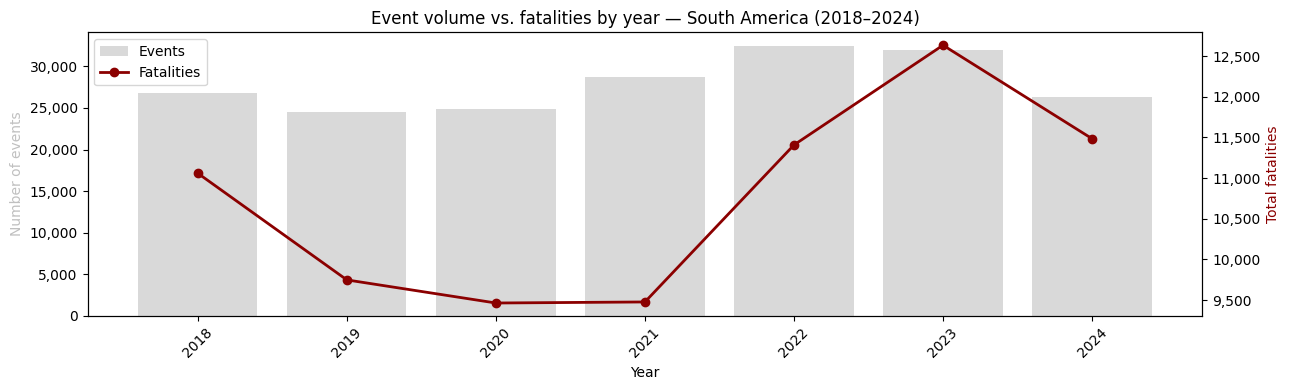

In [ ]:
# Data prep (filter dataframe by year, calculate total events and fatalities for each year).
yearly = df_filtered.groupby('year').agg(
    events     = ('event_date', 'count'), # Count of events per year
    fatalities = ('fatalities', 'sum')   # Sum of fatalities per year
).reset_index() # Reset index to turn 'year' back into a column

# Figure/axes initialization (size, 1 & 2 axes).
fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()

# Plot events as bar chart on ax1, fatalities as line chart on ax2.
ax1.bar(yearly['year'], yearly['events'], color='silver', alpha=0.6, label='Events')
ax2.plot(yearly['year'], yearly['fatalities'], color='darkred',
         marker='o', linewidth=2, label='Fatalities')

# Customization, labelling and colouring.
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of events', color='silver')
ax2.set_ylabel('Total fatalities', color='darkred')
ax1.set_title('Event volume vs. fatalities by year — South America (2018–2024)')
ax1.set_xticks(yearly['year'])
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Produce labels for both axes and legend.
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Tighten layout, save and display.
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig_events_fatalities_year.png', dpi=150)
plt.show()

Event volume evidently **doesn't** proportionally correlate with fatalities, as hypothesised. Number of events stays comparatively consistent, with a slight peak in 2022 and 2023, whilst fatalities hugely diverge between expected pandemic-era lows in 2020 and 2021 and sudden jumps to above 12,500 in 2023. Deeper analysis in notebook **03_analysis.ipynb** will explore the reason for these highs, going into variation by state and exploring whether fatalities were state or non-state based (and why).

Next, bring in the further analytical layer of the state and non-state basis of violent events (and fatalities). The actor-labelling in notebook 1 allows us to compare the numbers of both - we have seen the raw figures, but need to compare year-on-year. Some events will be driven by both state and non-state actors, often in conflict with one another, so this is to be expected in visualisation.

graph

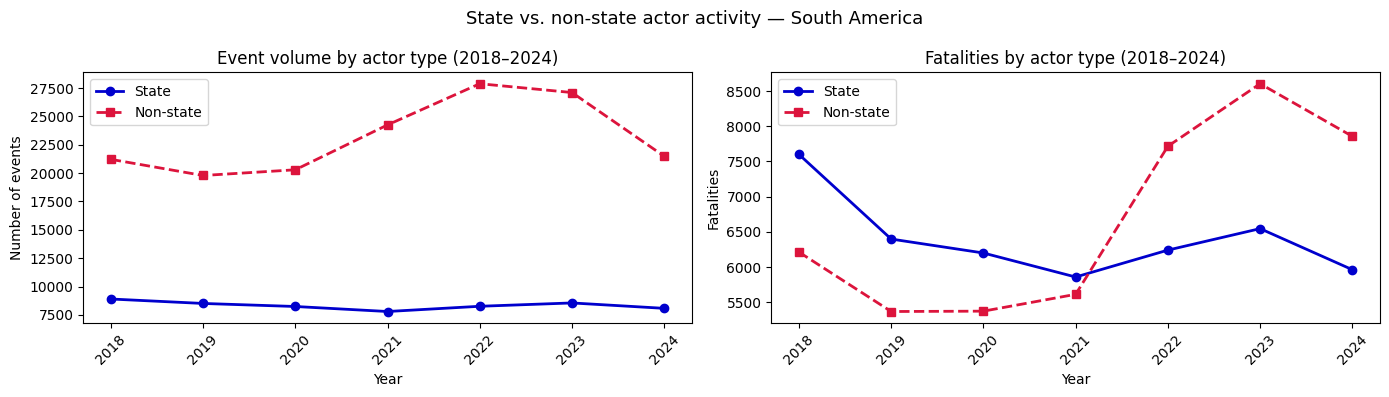

In [ ]:
# Data prep (define state & non-state subset by flags on dataframe).
state_events     = df_filtered[df_filtered['is_state_actor_event'] == 1]
non_state_events = df_filtered[df_filtered['is_non_state_actor_event'] == 1]

# Group state actor events by year, calculate event & fatalities count.
state_yearly = state_events.groupby('year').agg(
    events     = ('event_date', 'count'),
    fatalities = ('fatalities', 'sum')
).reset_index()

# GGroup non-state actor events by year, calculate event & fatalities count.
non_state_yearly = non_state_events.groupby('year').agg(
    events     = ('event_date', 'count'),
    fatalities = ('fatalities', 'sum')
).reset_index()

# Create figure with two subplots, one row and two columns.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot left subplot and mark title, legend etc.
axes[0].plot(state_yearly['year'], state_yearly['events'],
             marker='o', color='mediumblue', label='State', linewidth=2)
axes[0].plot(non_state_yearly['year'], non_state_yearly['events'],
             marker='s', color='crimson', label='Non-state', linewidth=2, linestyle='--')
axes[0].set_title('Event volume by actor type (2018–2024)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of events')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Plot right subplot and mark title, legend etc.
axes[1].plot(state_yearly['year'], state_yearly['fatalities'],
             marker='o', color='mediumblue', label='State', linewidth=2)
axes[1].plot(non_state_yearly['year'], non_state_yearly['fatalities'],
             marker='s', color='crimson', label='Non-state', linewidth=2, linestyle='--')
axes[1].set_title('Fatalities by actor type (2018–2024)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Fatalities')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

# Add title, tight layout, save and display.
plt.suptitle('State vs. non-state actor activity — South America', fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig_state_nonstate_yearly.png', dpi=150)
plt.show()

Event volume again highlights the consistency of event numbers over time, but now shows the clear divergence between state-based and non-state-based violence. The high violence of 2022 and 2023 must be further analysed, as the rise in it is evidently driven by non-state groups.

Fatalities shows a more unique picture, with state-based fatalities higher prior to the pandemic, and then a sudden increase afterwards to the violent 2022-2024 period. Of course the sudden inversing of fatalities must be analysed overall, but of particular interest in notebook 3 will be the lethality of state-based violence; state forces maintain high levels of fatalities, despite having few fewer associated events across the entire dataset and each year.

However, baseline value plotting does not allow us to analyse distribution; we cannot know if sudden spikes in fatalities are due to certain particularly lethal events.

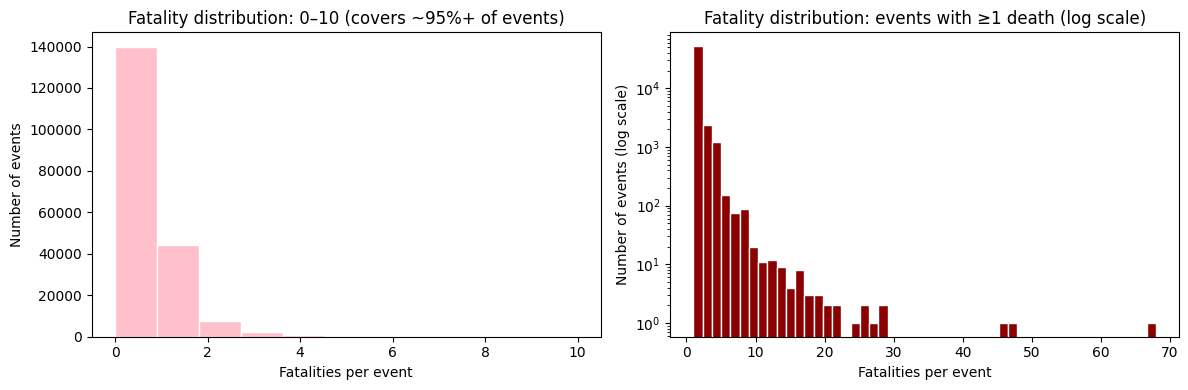

Fatality percentiles (all events):
  50th percentile: 0
  75th percentile: 1
  90th percentile: 1
  95th percentile: 2
  99th percentile: 3
  100th percentile: 68

Top 1% of events account for 13.0%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot left histogram for majority of fatalities (0-10).
axes[0].hist(df_filtered[df_filtered['fatalities'] <= 10]['fatalities'],
             bins=11, color='pink', edgecolor='white')
axes[0].set_title('Fatality distribution: 0–10 (covers ~95%+ of events)')
axes[0].set_xlabel('Fatalities per event')
axes[0].set_ylabel('Number of events')

# Plot right log-scale histogram for full range of fatalities.
axes[1].hist(df_filtered[df_filtered['fatalities'] > 0]['fatalities'],
             bins=50, color='darkred', edgecolor='white', log=True)
axes[1].set_title('Fatality distribution: events with ≥1 death (log scale)')
axes[1].set_xlabel('Fatalities per event')
axes[1].set_ylabel('Number of events (log scale)')

# Adjust layout, save and display.
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig_fatality_distribution.png', dpi=150)
plt.show()

# Calculate fatality percentile breakdown and print.
print("Fatality percentiles (all events):")
for p in [50, 75, 90, 95, 99, 100]:
    print(f"  {p}th percentile: {df_filtered['fatalities'].quantile(p/100):.0f}")

# Calculate % contribution of the top 1% deadliest events to total and print.
top1pct = df_filtered.nlargest(int(len(df_filtered) * 0.01), 'fatalities')
print(f"\nTop 1% of events account for "
      f"{top1pct['fatalities'].sum() / df_filtered['fatalities'].sum() * 100:.1f}%")

The left histogram highlights the intensely varied distribution of fatalities; a large majority of political violence results in no fatalities, around 44,000 result in 1, and frequency drops thereafter. Yet mean fatalities of course sit above 0, as it is pulled upward by the top 1% of high casualty events (accounting for 13% of all fatalities). No distinct clustering on either histogram indicates high-casualty events are indeed independent, and not the result of particular violence in a particular state.

Subsequent data analysis in notebook 3 ought to use median, rather than mean, avoiding including anomalies in total aggregates. Analysis ought not disregard these events, i.e. those around 46-47 and 67, and should include an aggregate with the top 1% of events to test robustness of findings.

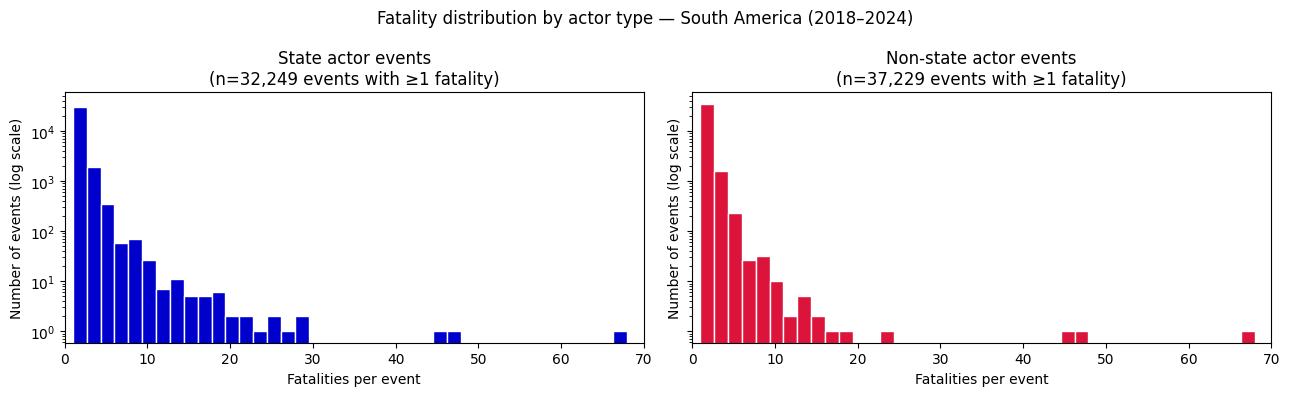

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

# Take right histogram and loop through each subplot for state actors and non-state actors
for ax, subset, label, color in zip(
    axes,
    [state_events, non_state_events],
    ['State actor events', 'Non-state actor events'],
    ['mediumblue', 'crimson']
):
    lethal = subset[subset['fatalities'] > 0]['fatalities']
# Plot histogram with log scale, title, label etc.
    ax.hist(lethal, bins=40, color=color, edgecolor='white', log=True)
    ax.set_title(f'{label}\n(n={len(lethal):,} events with ≥1 fatality)')
    ax.set_xlabel('Fatalities per event')
    ax.set_ylabel('Number of events (log scale)')
    ax.set_xlim(0, df_filtered['fatalities'].max() + 2)
plt.suptitle('Fatality distribution by actor type — South America (2018–2024)',
             fontsize=12)

# Adjust layout, save and display.
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig_distribution_by_actor.png', dpi=150)
plt.show()

Evidently, both actors have similar distribution curves of lethality, with particularly high outliers above 30 always involving both actors. However, notebook 3 analysis ought to note the comparably less steep drop-off of state-based violence, with considerable state-based events in the 10-30 fatalities range.

A quick side-by-side stripplot distribution will allow us to double-check differences in distribution regarding the 'tails' of the curve.

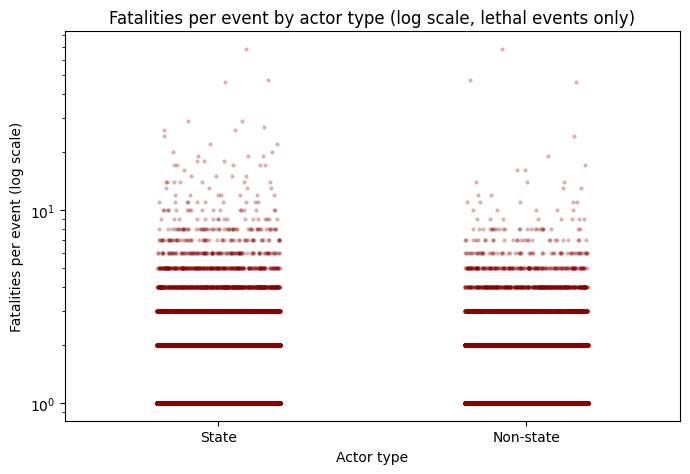

Summary statistics — lethal events only:
             count  mean   std  min  25%  50%  75%   max
actor                                                   
Non-state  37229.0  1.26  0.88  1.0  1.0  1.0  1.0  68.0
State      32249.0  1.39  1.20  1.0  1.0  1.0  1.0  68.0


In [ ]:
# Join state and non-state data into combined dataframe, assign actor types.
plot_data = pd.concat([
    state_events[state_events['fatalities'] > 0][['fatalities']].assign(actor='State'),
    non_state_events[non_state_events['fatalities'] > 0][['fatalities']].assign(actor='Non-state')
])

fig, ax = plt.subplots(figsize=(7, 5))

# Plot stripplot of individual fatality counts, adding dot formatting and jitter for visibility.
sns.stripplot(x='actor', y='fatalities', data=plot_data, ax=ax,
              color='darkred',
              marker='o', s=3, alpha=0.3,
              jitter=0.2)

# Customize plot log scale, title, labels.
ax.set_yscale('log')
ax.set_title('Fatalities per event by actor type (log scale, lethal events only)')
ax.set_xlabel('Actor type')
ax.set_ylabel('Fatalities per event (log scale)')
plt.suptitle('')  # Suppress pandas auto-title to avoid redundancy

# Adjust layout, save and display.
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig_boxplot_actor_fatalities.png', dpi=150)
plt.show()

# Print summary statistics with plot for later report.
print("Summary statistics — lethal events only:")
print(plot_data.groupby('actor')['fatalities'].describe().round(2))

Thicker 'tail' of state-based lethality confirmed with side-by-side plotting, prescient for notebook 3 analysis. Printed summary statistics certify values to add into final report when discussing quantitative analyses.

Along the lines of the summary stats above, identify mean and median lethality per actor event for later usage.

In [ ]:
# Group data by actor type, aggregate fatality statistics, confirm metrics for actor lethality.
# no. events by actor, no. fatality events, % lethal events, average fatalities/event, median fatalities/event, 90th percentile, 99th percentile, max. fatalities.
lethality = df_filtered.groupby(
    df_filtered['is_state_actor_event'].map({1: 'State', 0: 'Non-state'})
)['fatalities'].agg(
    total_events   = 'count', # Total number of events for the actor type
    lethal_events  = lambda x: (x > 0).sum(), # Number of events with at least one fatality
    pct_lethal     = lambda x: round((x > 0).mean() * 100, 1), # Percentage of lethal events
    mean_fatalities = 'mean', # Average fatalities per event
    median_fatalities = 'median', # Median fatalities per event
    p90_fatalities = lambda x: x.quantile(0.9), # 90th percentile of fatalities
    p99_fatalities = lambda x: x.quantile(0.99), # 99th percentile of fatalities
    max_fatalities = 'max' # Maximum fatalities in a single event
).round(3)

print(lethality)

                      total_events  lethal_events  pct_lethal  \
is_state_actor_event                                            
Non-state                   137423          23694        17.2   
State                        58384          32249        55.2   

                      mean_fatalities  median_fatalities  p90_fatalities  \
is_state_actor_event                                                       
Non-state                       0.222                0.0             1.0   
State                           0.767                1.0             2.0   

                      p99_fatalities  max_fatalities  
is_state_actor_event                                  
Non-state                        3.0              16  
State                            4.0              68  


Reaffirming findings from the charts above, the most pressing output is the difference between *pct_lethal* - state-based violence is around three times more likely (55% lethality vs. 17% lethality) to result in death than non-state-based violence.

Higher state lethality is reflected in the mean and median fatalities alike, with the median in particular demonstrating the typical state event will end in lethality (extreme cases alone are not pulling up the figures; non-state actors share the same anomalies). The typical non-state event records no fatalities. Tail statistics on the 90th and 99th percentiles reiterate these differences, with state fatalities higher in both. Additionally, the deadliest state-based event dwarfs the deadliest non-state-based event in fatalities.

Non-state actors do generate approx. twice as many violent events total, so have statistical outweighing influencing per-event lethality, but the fact does remain that even in pure values alone state-based violence has 8,555 more lethal events than non-state actors.

We can extrapolate a clear difference in the character of violence; non-state actors are extensively violent (large in aggregate, not in fatality), whilst state actors are intensively violent (lesser in aggregate, more in fatality).


Notebook **03_analysis.ipynb** will expand on this analytical distinction, seeing whether the extensive-intensive dynamic holds over time and/or across/within countries, which event types cause this intensive lethality, and why the actor gap is so pronounced and changeable across the time period analysed.